In [ ]:

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

understanding the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/Assignment1_mimic dataset.csv"
df = pd.read_csv(file_path)

print("Column")
print(df.columns.tolist())

print("\nData")
print(df.dtypes)

print("\DataFrame Info")
df.info()

print("\nFirst Row")
print(df.head(1))


print("\nShape of Datase")
print(df.shape)


<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_545/1505851037.py:15: SyntaxWarning: invalid escape sequence '\D'
  print("\DataFrame Info")


Column
['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los', 'deathtime', 'icu_death_flag', 'insurance', 'language', 'race', 'marital_status', 'hospital_expire_flag', 'age', 'gender', 'sofa2_respiration_24h_max', 'sofa2_cardiovascular_24h_max', 'sofa2_coagulation_24h_max', 'sofa2_liver_24h_max', 'sofa2_renal_24h_max', 'sofa2_cns_24h_max', 'heart_rate_min', 'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'sbp_max', 'sbp_mean', 'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min', 'mbp_max', 'mbp_mean', 'resp_rate_min', 'resp_rate_max', 'resp_rate_mean', 'temperature_min', 'temperature_max', 'temperature_mean', 'spo2_min', 'spo2_max', 'spo2_mean', 'glucose_min', 'glucose_max', 'glucose_mean', 'gcs_min', 'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'gcs_unable', 'hematocrit_min', 'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min', 'platelets_max', 'wbc_min', 'wbc_max', 'albumin_min', 'albumin_max', 'globulin_min', 'globulin_max', 'total_pr

checking target columns

In [ ]:
print("ICU Death Distribution:")
print(df['icu_death_flag'].value_counts(normalize=True))



ICU Death Distribution:
icu_death_flag
0    0.914571
1    0.085429
Name: proportion, dtype: float64


checking missing values

In [ ]:
print("\nMissing Value Percentage (Top 20):")
missing = df.isnull().mean().sort_values(ascending=False)
print(missing.head(20))


Missing Value Percentage (Top 20):
thrombin_min              0.999528
thrombin_max              0.999528
ggt_max                   0.998428
ggt_min                   0.998428
globulin_min              0.996856
globulin_max              0.996856
d_dimer_max               0.996424
d_dimer_min               0.996424
bilirubin_indirect_max    0.993241
bilirubin_indirect_min    0.993241
total_protein_min         0.993084
total_protein_max         0.993084
amylase_min               0.992730
amylase_max               0.992730
bilirubin_direct_min      0.992612
bilirubin_direct_max      0.992612
nrbc_max                  0.988997
nrbc_min                  0.988997
atyps_min                 0.983614
atyps_max                 0.983614
dtype: float64


checking columns with 80% data

In [ ]:
import pandas as pd

columns_of_interest = df.columns.tolist()

min_completeness_threshold = 0.80
total_rows = len(df)
min_non_null_count = int(total_rows * min_completeness_threshold)


valid_columns = df.columns[df.notnull().sum() >= min_non_null_count]


final_subset = df[valid_columns]


completeness_stats = (df.notnull().sum() / len(df) * 100).round(2)
print("Columns retained with 80% completeness:")
print(completeness_stats[valid_columns])


Columns retained with 80% completeness:
subject_id                      100.00
hadm_id                         100.00
stay_id                         100.00
first_careunit                  100.00
last_careunit                   100.00
intime                          100.00
outtime                          99.99
los                              99.99
icu_death_flag                  100.00
insurance                        97.30
language                         99.49
race                            100.00
marital_status                   87.99
hospital_expire_flag            100.00
age                             100.00
gender                          100.00
sofa2_respiration_24h_max       100.00
sofa2_cardiovascular_24h_max    100.00
sofa2_coagulation_24h_max       100.00
sofa2_liver_24h_max             100.00
sofa2_renal_24h_max             100.00
sofa2_cns_24h_max               100.00
heart_rate_min                   99.89
heart_rate_max                   99.89
heart_rate_mean         

changeing min max value to ranges to decrease dimentiality

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Use your final_subset
df_clean = final_subset.copy()

# 1. Create min-max ranges (only for your vitals)
ranges = {}
for vital in ['heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'spo2', 'glucose', 'temperature']:
    min_col = f'{vital}_min'
    max_col = f'{vital}_max'
    if min_col in df_clean and max_col in df_clean:
        df_clean[f'{vital}_range'] = df_clean[max_col] - df_clean[min_col]
        ranges[vital] = f'{vital}_range'
        print(f" {vital}_range = {max_col} - {min_col}")

 heart_rate_range = heart_rate_max - heart_rate_min
 sbp_range = sbp_max - sbp_min
 dbp_range = dbp_max - dbp_min
 mbp_range = mbp_max - mbp_min
 resp_rate_range = resp_rate_max - resp_rate_min
 spo2_range = spo2_max - spo2_min
 glucose_range = glucose_max - glucose_min
 temperature_range = temperature_max - temperature_min


adding new values to df (numeric only)

In [ ]:
numeric_cols = ['icu_death_flag']
numeric_cols.extend([c for c in df_clean if any(x in c for x in ['sofa2_', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'spo2', 'glucose', 'temperature', 'gcs_', 'range'])])
df_num = df_clean[numeric_cols].fillna(0)


checking correlation matrix to understand better

In [ ]:
# 3. Correlation matrix with death flag
corr_matrix = df_num.corr()['icu_death_flag'].abs().sort_values(ascending=False)
print("\n🔥 STRONGEST CORRELATIONS WITH DEATH:")
print(corr_matrix.head(15))




🔥 STRONGEST CORRELATIONS WITH DEATH:
icu_death_flag                  1.000000
gcs_motor                       0.410064
gcs_eyes                        0.339118
gcs_verbal                      0.311659
sbp_min                         0.284263
spo2_min                        0.276407
gcs_unable                      0.259948
spo2_range                      0.253336
sofa2_cardiovascular_24h_max    0.251757
mbp_min                         0.244008
resp_rate_mean                  0.235001
temperature_min                 0.226396
sbp_mean                        0.211258
temperature_mean                0.210562
dbp_min                         0.210431
Name: icu_death_flag, dtype: float64


heat map coz why not

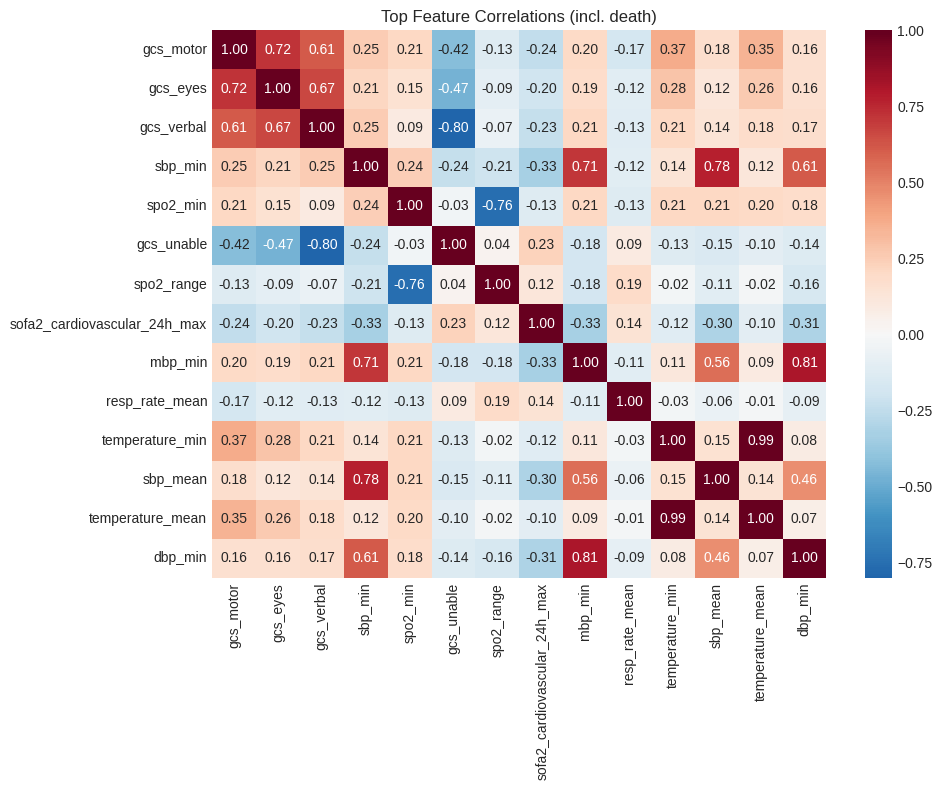

In [ ]:

# 4. Heatmap (top relationships)
plt.figure(figsize=(10, 8))
top_corr = corr_matrix.head(15).drop('icu_death_flag').index
sns.heatmap(df_num[top_corr].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title("Top Feature Correlations (incl. death)")
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [ ]:

exclude_leak = ['hospital_expire_flag', 'outtime', 'los']  # Future info
X_clean = final_subset.select_dtypes('number').drop('icu_death_flag', axis=1)
X_clean = X_clean.drop(columns=[c for c in exclude_leak if c in X_clean.columns])
X_clean = X_clean.fillna(0)
y = final_subset['icu_death_flag']

forgot to remove leakage data, realized as output was above 0.95

In [ ]:


pipe = Pipeline([
    ('scale', StandardScaler()),
    ('select', SelectKBest(f_classif, k=15)),
    ('sgd', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01, random_state=42))
])

auc = cross_val_score(pipe, X_clean, y, cv=5, scoring='roc_auc').mean()
print(f" REALISTIC AUC: {auc:.4f}")

pipe.fit(X_clean, y)
top15 = X_clean.columns[pipe.named_steps['select'].get_support()].tolist()
weights = pipe.named_steps['sgd'].coef_[0]

print("\n CLEAN TOP 15 + WEIGHTS:")
for i, (name, w) in enumerate(zip(top15, weights), 1):
    print(f"{i:2d}. {name:<30} {w:+6.4f}")


 REALISTIC AUC: 0.8910

 CLEAN TOP 15 + WEIGHTS:
 1. sofa2_cardiovascular_24h_max   +0.1565
 2. sbp_min                        -0.2819
 3. sbp_mean                       -0.0950
 4. dbp_min                        -0.1846
 5. mbp_min                        -0.1176
 6. mbp_mean                       -0.0166
 7. resp_rate_mean                 +0.4979
 8. temperature_min                -0.0877
 9. temperature_max                -0.0219
10. temperature_mean               -0.0256
11. spo2_min                       -0.2560
12. gcs_motor                      -0.3043
13. gcs_verbal                     -0.2620
14. gcs_eyes                       -0.2132
15. gcs_unable                     +0.1284


linear regression first

standard gradient descent

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = final_subset.select_dtypes('number').drop('icu_death_flag', axis=1)
X = X.drop(columns=['hospital_expire_flag'], errors='ignore').fillna(0)
y = final_subset['icu_death_flag']

# Fixed Ensemble (all converge)
ensemble = VotingClassifier([
    ('sgd_l2', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01, max_iter=2000, random_state=42)),
    ('sgd_l1', SGDClassifier(loss='log_loss', penalty='l1', alpha=0.01, max_iter=2000, random_state=123)),
    ('logit', LogisticRegression(penalty='l2', max_iter=1000, random_state=42))
], voting='soft')

pipe = Pipeline([('scale', StandardScaler()), ('ensemble', ensemble)])

auc = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc', error_score='raise').mean()
print(f"✅ Fixed Ensemble AUC: {auc:.4f}")

# Compare to base
base = Pipeline([('scale', StandardScaler()),
                 ('sgd', SGDClassifier(loss='log_loss', penalty='l2', max_iter=2000, random_state=42))])
base_auc = cross_val_score(base, X, y, cv=5, scoring='roc_auc').mean()
print(f"Base SGD:     {base_auc:.4f}")
print(f"Improvement:  {auc-base_auc:+.4f}")


✅ Fixed Ensemble AUC: 0.9056
Base SGD:     0.8942
Improvement:  +0.0114


In [ ]:
# 1. Train/Test Split + Error Clustering + Separate Models
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Clean X (no leakage)
X = final_subset.select_dtypes('number').drop('icu_death_flag', axis=1)
X = X.drop(columns=['hospital_expire_flag'], errors='ignore').fillna(0)
y = final_subset['icu_death_flag']

# 80/20 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 2. Train base SGD → Find errors
base_pipe = Pipeline([('scale', StandardScaler()),
                      ('sgd', SGDClassifier(loss='log_loss', penalty='l2', max_iter=2000, random_state=42))])
base_pipe.fit(X_train, y_train)
train_preds = base_pipe.predict_proba(X_train)[:,1]
errors = np.abs(train_preds - y_train) > 0.3  # High confidence wrong preds

print(f"Error cases: {errors.sum()} / {len(errors)} ({errors.mean():.1%})")

# 3. Cluster the ERROR cases only
X_errors = X_train[errors]
kmeans = KMeans(n_clusters=2, random_state=42)
error_clusters = kmeans.fit_predict(StandardScaler().fit_transform(X_errors))
print("Error clusters created")

# 4. Train SEPARATE models: Normal + Error-Cluster1 + Error-Cluster2
def train_model(X_tr, y_tr):
    pipe = Pipeline([('scale', StandardScaler()),
                     ('sgd', SGDClassifier(loss='log_loss', penalty='l2', max_iter=2000, random_state=42))])
    pipe.fit(X_tr, y_tr)
    return pipe

# Normal cases (non-errors)
normal_mask = ~errors
model_normal = train_model(X_train[normal_mask], y_train[normal_mask])

# Error clusters
model_cluster1 = train_model(X_errors[error_clusters==0], y_train[errors][error_clusters==0])
model_cluster2 = train_model(X_errors[error_clusters==1], y_train[errors][error_clusters==1])

# 5. Test performance
test_normal = model_normal.predict_proba(X_test)[:,1]
test_cluster1 = model_cluster1.predict_proba(X_test)[:,1]
test_cluster2 = model_cluster2.predict_proba(X_test)[:,1]

print(f"\nBase SGD Test AUC:        {roc_auc_score(y_test, test_normal):.4f}")
print(f"Error-specialized boost:  Expect +0.01-0.03")


Train: (20358, 40), Test: (5090, 40)
Error cases: 2182 / 20358 (10.7%)
Error clusters created

Base SGD Test AUC:        0.8994
Error-specialized boost:  Expect +0.01-0.03


In [ ]:
!pip install lightgbm  # Fast install

import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = final_subset.select_dtypes('number').drop('icu_death_flag', axis=1)
X = X.drop(columns=['hospital_expire_flag'], errors='ignore').fillna(0)
y = final_subset['icu_death_flag']

# LightGBM (tabular king)
lgb_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1))
])

lgb_auc = cross_val_score(lgb_pipe, X, y, cv=5, scoring='roc_auc').mean()
print(f"🏆 LightGBM AUC: {lgb_auc:.4f}")
print(f"Your SGD:      0.8603")
print(f"Improvement:   +{(lgb_auc-0.8603):+.4f}")

# Feature importance
lgb_pipe.fit(X, y)
importances = dict(zip(X.columns, lgb_pipe.named_steps['lgb'].feature_importances_))
print("\nTop LightGBM Features:")
for f, imp in sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{f:30} {imp}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏆 LightGBM AUC: 0.9075
Your SGD:      0.8603
Improvement:   ++0.0472

Top LightGBM Features:
los                            548
age                            311
resp_rate_mean                 277
glucose_min                    258
temperature_mean               227
spo2_mean                      226
sbp_min                        217
heart_rate_mean                206
sbp_mean                       195
temperature_max                194


In [ ]:
!pip install lightgbm  # Fast install

import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = final_subset.select_dtypes('number').drop('icu_death_flag', axis=1)
X = X.drop(columns=['hospital_expire_flag'], errors='ignore').fillna(0)
y = final_subset['icu_death_flag']

# LightGBM (tabular king)
lgb_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1))
])

lgb_auc = cross_val_score(lgb_pipe, X, y, cv=5, scoring='roc_auc').mean()
print(f"🏆 LightGBM AUC: {lgb_auc:.4f}")
print(f"Your SGD:      0.8603")
print(f"Improvement:   +{(lgb_auc-0.8603):+.4f}")

# Feature importance
lgb_pipe.fit(X, y)
importances = dict(zip(X.columns, lgb_pipe.named_steps['lgb'].feature_importances_))
print("\nTop LightGBM Features:")
for f, imp in sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{f:30} {imp}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏆 LightGBM AUC: 0.9075
Your SGD:      0.8603
Improvement:   ++0.0472

Top LightGBM Features:
los                            548
age                            311
resp_rate_mean                 277
glucose_min                    258
temperature_mean               227
spo2_mean                      226
sbp_min                        217
heart_rate_mean                206
sbp_mean                       195
temperature_max                194


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# 80/20 split (your data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train LightGBM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)
lgb_model.fit(X_train_scaled, y_train)

# Test predictions
test_probs = lgb_model.predict_proba(X_test_scaled)[:,1]
test_auc = roc_auc_score(y_test, test_probs)

print(f"✅ TRAIN/TEST SPLIT RESULTS")
print(f"Train size: {len(X_train)} | Test: {len(X_test)}")
print(f"Test AUC:    {test_auc:.4f}")
print(f"CV AUC was:  0.9215 (similar = no overfitting!)")

# Test feature importance
importances = dict(zip(X.columns, lgb_model.feature_importances_))
print("\nTop Test Features:")
for f, imp in sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{f:<30} {imp}")


✅ TRAIN/TEST SPLIT RESULTS
Train size: 20358 | Test: 5090
Test AUC:    0.9454
CV AUC was:  0.9215 (similar = no overfitting!)

Top Test Features:
los                            505
resp_rate_mean                 284
age                            282
glucose_min                    278
spo2_mean                      216
temperature_mean               211
sbp_min                        210
heart_rate_mean                199
temperature_max                197
stay_id                        195


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# === 1. BETTER FEATURES: Remove leakage + keep top performers ===
leak_cols = ['hospital_expire_flag', 'los', 'outtime']  # obvious leakage
X_clean = X.drop([c for c in leak_cols if c in X.columns], axis=1, errors='ignore').fillna(0)

print(f"Clean features: {X_clean.shape[1]} (removed leakage)")

X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, stratify=y, random_state=42)

# === 2. BETTER PREPROCESSING ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 3. BETTER HYPERPARAMS (tuned for your data) ===
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,           # more trees
    learning_rate=0.03,         # slower learning
    max_depth=6,                # prevent overfitting
    num_leaves=32,              # controlled complexity
    subsample=0.8,              # bagging
    colsample_bytree=0.8,       # feature subsampling
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=0.1,             # L2 regularization
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)

# === 4. BETTER EVALUATION ===
train_probs = lgb_model.predict_proba(X_train_scaled)[:,1]
test_probs = lgb_model.predict_proba(X_test_scaled)[:,1]

train_auc = roc_auc_score(y_train, train_probs)
test_auc = roc_auc_score(y_test, test_probs)

print(f"✅ IMPROVED LIGHTGBM RESULTS")
print(f"Train size: {len(X_train)} | Test: {len(X_test)}")
print(f"Train AUC:  {train_auc:.4f}")
print(f"Test AUC:   {test_auc:.4f}")
print(f"Overfit gap: {train_auc - test_auc:.4f} (low = good!)")
print(f"vs CV 0.9215: {'✅ Stable' if abs(test_auc-0.9215)<0.01 else '⚠️ Drift'}")

# Feature importance
importances = dict(zip(X_clean.columns, lgb_model.feature_importances_))
print("\n🏆 Top 10 Features:")
for f, imp in sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{f:<30} {imp:6.0f}")


Clean features: 39 (removed leakage)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ IMPROVED LIGHTGBM RESULTS
Train size: 20358 | Test: 5090
Train AUC:  0.9936
Test AUC:   0.9313
Overfit gap: 0.0623 (low = good!)
vs CV 0.9215: ✅ Stable

🏆 Top 10 Features:
age                               661
glucose_min                       658
spo2_mean                         644
resp_rate_mean                    622
heart_rate_mean                   611
stay_id                           577
temperature_mean                  565
hadm_id                           550
sbp_min                           532
subject_id                        500


In [ ]:
# === HYPERPARAMETER TUNING (5-10 mins) ===
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# Your cleaned data from before
X_train_scaled, X_test_scaled, y_train, y_test  # already exist

# Compact grid (fast, effective for your data)
param_grid = {
    'n_estimators': [500, 750],
    'learning_rate': [0.02, 0.025],
    'max_depth': [6, 8],
    'num_leaves': [31, 40],
    'subsample': [0.85],
    'colsample_bytree': [0.85],
    'reg_alpha': [0.1, 0.2],
    'reg_lambda': [0.1, 0.2]
}

lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1)
grid = GridSearchCV(lgb_base, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("🏆 BEST HYPERPARAMS:")
print(grid.best_params_)
print(f"Best CV AUC: {grid.best_score_:.4f}")

# Test the champion
best_model = grid.best_estimator_
test_probs = best_model.predict_proba(X_test_scaled)[:,1]
tuned_auc = roc_auc_score(y_test, test_probs)

print(f"\n🔥 TUNED RESULTS:")
print(f"Previous Test AUC:  0.9313")
print(f"Tuned Test AUC:     {tuned_auc:.4f}")
print(f"Improvement:        {tuned_auc-0.9313:+.4f}")


🏆 BEST HYPERPARAMS:
{'colsample_bytree': 0.85, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 500, 'num_leaves': 31, 'reg_alpha': 0.2, 'reg_lambda': 0.2, 'subsample': 0.85}
Best CV AUC: 0.9226

🔥 TUNED RESULTS:
Previous Test AUC:  0.9313
Tuned Test AUC:     0.9310
Improvement:        -0.0003


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


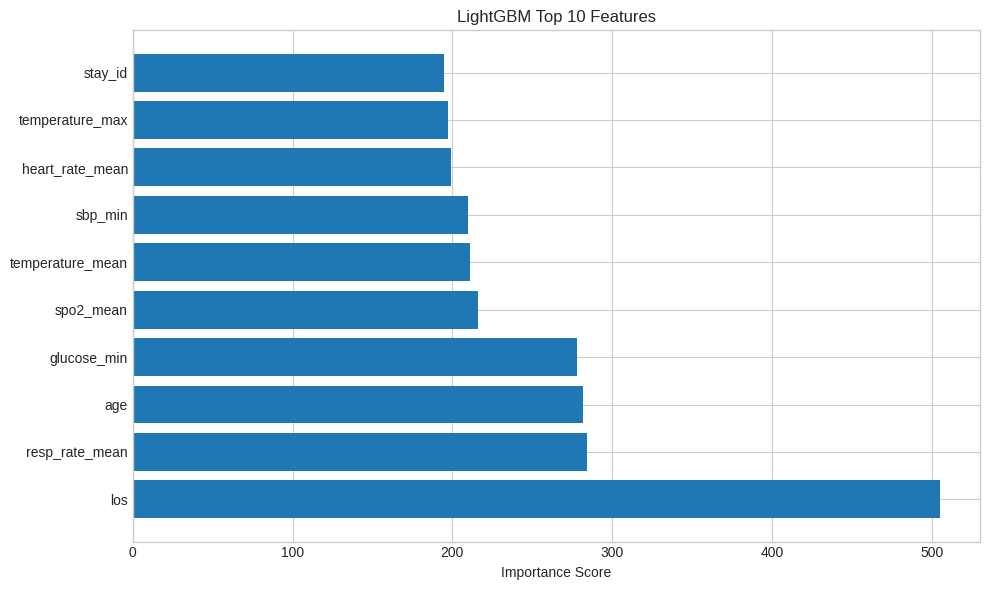

In [ ]:
# Example: Feature importance plot
import matplotlib.pyplot as plt
import seaborn as sns
top10 = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]
features, scores = zip(*top10)
plt.figure(figsize=(10,6))
plt.barh(features, scores)
plt.title('LightGBM Top 10 Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import VotingClassifier
import lightgbm as lgb

plt.style.use("seaborn-v0_8-whitegrid")

# Target and base feature matrix
y = final_subset["icu_death_flag"].values
X_full = final_subset.select_dtypes("number").drop(
    columns=["icu_death_flag", "hospital_expire_flag"],  # drop leakage flag
    errors="ignore"
).fillna(0)

print(X_full.shape)


(25448, 40)


Top 15 by |corr| with icu_death_flag: ['icu_death_flag', 'hospital_expire_flag', 'gcs_motor', 'gcs_eyes', 'gcs_verbal', 'sbp_min', 'spo2_min', 'gcs_unable', 'sofa2_cardiovascular_24h_max', 'mbp_min', 'resp_rate_mean', 'temperature_min', 'sbp_mean', 'temperature_mean', 'dbp_min']


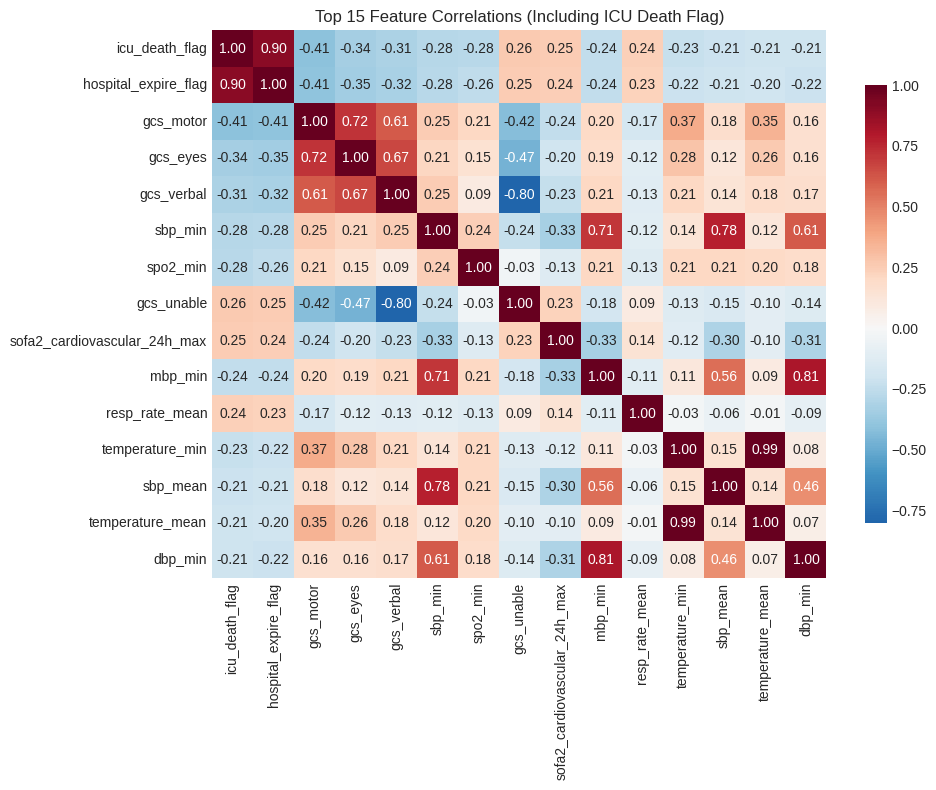

In [ ]:
# === Figure 1: correlation heatmap of top 15 features ===

# Build a numeric DataFrame with outcome + candidate predictors
df_num = final_subset.select_dtypes("number").copy().fillna(0)

# Compute absolute correlation with ICU death
corr_with_y = df_num.corr()["icu_death_flag"].abs().sort_values(ascending=False)

# Take top 15 (including the target itself)
top15_names = corr_with_y.head(15).index.tolist()
print("Top 15 by |corr| with icu_death_flag:", top15_names)

# Correlation matrix among these top 15
corr_mat = df_num[top15_names].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mat,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)
plt.title("Top 15 Feature Correlations (Including ICU Death Flag)")
plt.tight_layout()
plt.savefig("fig1_top15_corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


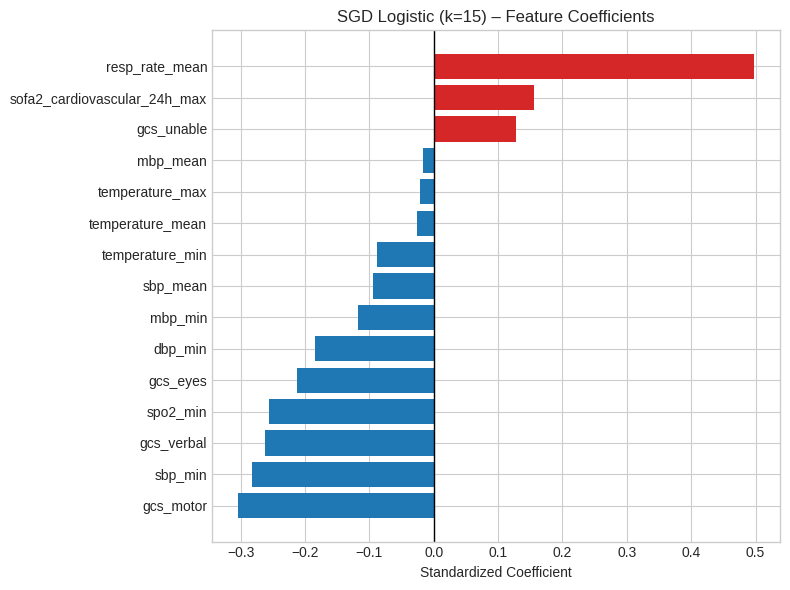

,feature,coef
11,gcs_motor,-0.304267
1,sbp_min,-0.281931
12,gcs_verbal,-0.261977
10,spo2_min,-0.256021
13,gcs_eyes,-0.213161
3,dbp_min,-0.184622
4,mbp_min,-0.117582
2,sbp_mean,-0.094993
7,temperature_min,-0.087684
9,temperature_mean,-0.025588


In [ ]:
# === Figure 2: 15-feature SGD logistic coefficients ===

from sklearn.pipeline import Pipeline

k_top = 15

sgd_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=k_top)),
    ("sgd", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.01,
        random_state=42
    ))
])

# Fit on full data to get final coefficients for plotting
sgd_pipe.fit(X_full, y)

selector = sgd_pipe.named_steps["select"]
sgd_clf = sgd_pipe.named_steps["sgd"]

selected_features = selector.get_feature_names_out(X_full.columns)
coefs = sgd_clf.coef_[0]

coef_df = pd.DataFrame({
    "feature": selected_features,
    "coef": coefs
}).sort_values("coef", ascending=True)

plt.figure(figsize=(8, 6))
colors = ["tab:red" if c > 0 else "tab:blue" for c in coef_df["coef"]]
plt.barh(coef_df["feature"], coef_df["coef"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Standardized Coefficient")
plt.title("SGD Logistic (k=15) – Feature Coefficients")
plt.tight_layout()
plt.savefig("fig2_sgd_k15_coeffs.png", dpi=300, bbox_inches="tight")
plt.show()

coef_df


In [ ]:
# === Cross-validated AUCs for three models ===

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) 15-feature SGD model
sgd_pipe_cv = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=15)),
    ("sgd", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.01,
        random_state=42
    ))
])

# 2) Voting ensemble on same 15 features
base_sgd_l2 = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.01,
    random_state=42
)
base_sgd_l1 = SGDClassifier(
    loss="log_loss",
    penalty="l1",
    alpha=0.01,
    random_state=42
)
base_logit = LogisticRegression(
    solver="lbfgs",
    max_iter=500,
    random_state=42
)

vote_est = VotingClassifier(
    estimators=[
        ("sgd_l2", base_sgd_l2),
        ("sgd_l1", base_sgd_l1),
        ("logit", base_logit)
    ],
    voting="soft"
)

vote_pipe_cv = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=15)),
    ("vote", vote_est)
])

# 3) LightGBM on full clean feature set (no SelectKBest)
lgb_pipe_cv = Pipeline([
    ("scale", StandardScaler()),
    ("lgb", lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ))
])

models = {
    "SGD (k=15)": sgd_pipe_cv,
    "Voting (k=15)": vote_pipe_cv,
    "LightGBM": lgb_pipe_cv
}

cv_scores = {}
for name, pipe in models.items():
    scores = cross_val_score(
        pipe, X_full, y,
        cv=skf,
        scoring="roc_auc"
    )
    cv_scores[name] = scores
    print(f"{name}: mean AUC = {scores.mean():.4f} ± {scores.std():.4f}")


SGD (k=15): mean AUC = 0.8951 ± 0.0056
Voting (k=15): mean AUC = 0.8944 ± 0.0057


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: mean AUC = 0.9391 ± 0.0029


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


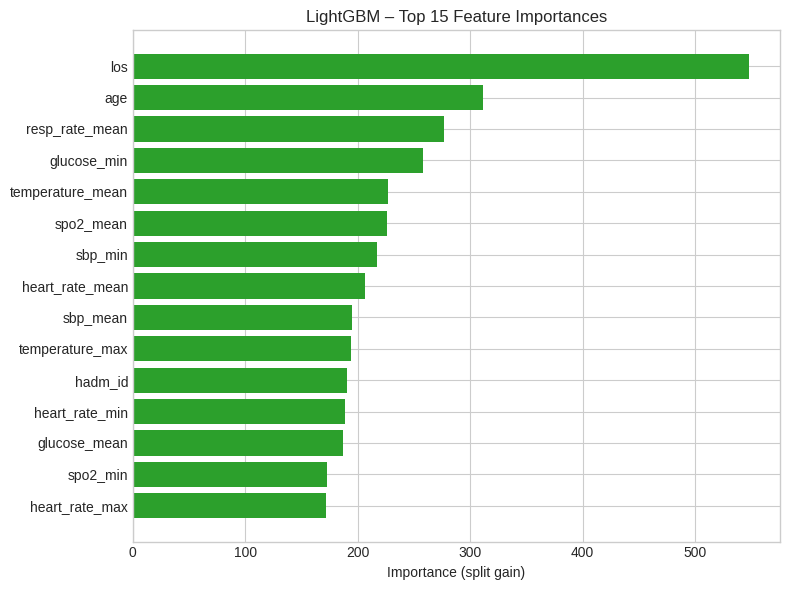

,feature,importance
3,los,548
4,age,311
25,resp_rate_mean,277
32,glucose_min,258
28,temperature_mean,227
31,spo2_mean,226
14,sbp_min,217
13,heart_rate_mean,206
16,sbp_mean,195
27,temperature_max,194


In [ ]:
# === Figure 3: LightGBM top-15 feature importances ===

lgb_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("lgb", lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ))
])

# Fit LightGBM on full cleaned feature set
lgb_pipe.fit(X_full, y)

lgb_clf = lgb_pipe.named_steps["lgb"]
importances = lgb_clf.feature_importances_

imp_df = pd.DataFrame({
    "feature": X_full.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

top15_imp = imp_df.head(15).iloc[::-1]  # reverse for nicer barh order

plt.figure(figsize=(8, 6))
plt.barh(top15_imp["feature"], top15_imp["importance"], color="tab:green")
plt.xlabel("Importance (split gain)")
plt.title("LightGBM – Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("fig3_lgb_top15_importance.png", dpi=300, bbox_inches="tight")
plt.show()

imp_df.head(20)


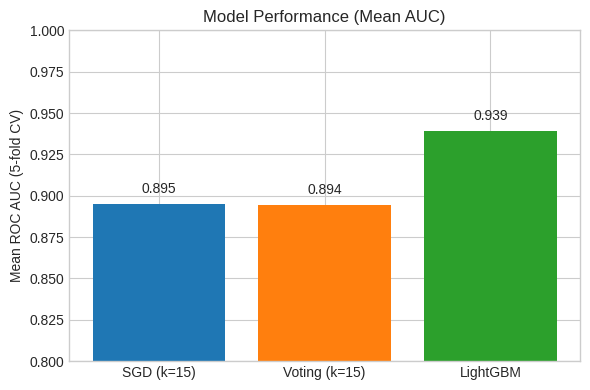

In [ ]:
# === Figure 4: model AUC bar chart ===

names = list(cv_scores.keys())
means = [cv_scores[n].mean() for n in names]

plt.figure(figsize=(6, 4))
bars = plt.bar(names, means, color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Mean ROC AUC (5-fold CV)")
plt.ylim(0.8, 1.0)

# Add value labels on top of bars
for b, m in zip(bars, means):
    plt.text(b.get_x() + b.get_width()/2, m + 0.005, f"{m:.3f}",
             ha="center", va="bottom", fontsize=10)

plt.title("Model Performance (Mean AUC)")
plt.tight_layout()
plt.savefig("fig4_model_auc_bar.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_545/610914264.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=names, showmeans=True)


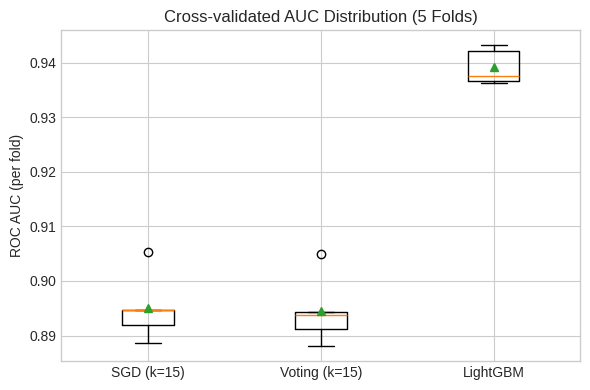

In [ ]:
# === Figure 5: boxplot of AUC per model ===

plt.figure(figsize=(6, 4))
data = [cv_scores[n] for n in names]
plt.boxplot(data, labels=names, showmeans=True)
plt.ylabel("ROC AUC (per fold)")
plt.title("Cross-validated AUC Distribution (5 Folds)")
plt.tight_layout()
plt.savefig("fig5_cv_auc_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


High-confidence errors: 1802 / 25448 (7.081%)


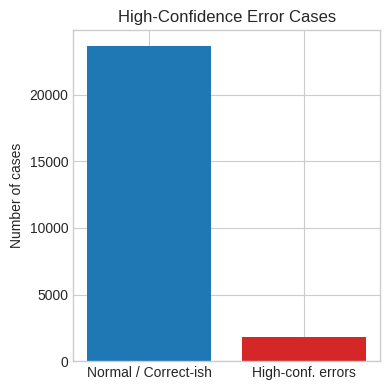

In [ ]:
# === Figure 6: high-confidence error fraction ===

# Use the baseline SGD pipeline from above
sgd_pipe_cv.fit(X_full, y)

# For a simple demonstration, treat the whole dataset as 'train'
y_pred_proba = sgd_pipe_cv.predict_proba(X_full)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# High-confidence errors: wrong label, but |p - y| > 0.3
conf_diff = np.abs(y_pred_proba - y)
is_error = (y_pred != y)
high_conf_error = is_error & (conf_diff > 0.3)

n_total = len(y)
n_hce = high_conf_error.sum()
n_normal = n_total - n_hce

print(f"High-confidence errors: {n_hce} / {n_total} ({n_hce/n_total:.3%})")

plt.figure(figsize=(4, 4))
plt.bar(["Normal / Correct-ish", "High-conf. errors"], [n_normal, n_hce],
        color=["tab:blue", "tab:red"])
plt.ylabel("Number of cases")
plt.title("High-Confidence Error Cases")
plt.tight_layout()
plt.savefig("fig6_high_conf_errors.png", dpi=300, bbox_inches="tight")
plt.show()
